In [3]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from ConstantPropagation import ConstantPropagation
from qiskit.circuit.classical import expr

## Test cases

In [27]:
def one_mid_meas_pure_state():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])

    return qc

def one_mid_meas_mixed_state():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.cx(qr[0], cr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])

    return qc


def reset_pure_state():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])
    qc.reset(qr[0])
    qc.x(qr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])

    return qc

def mid_meas_whole_reg_true():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.x(qr[0])
    qc.x(qr[1])

    qc.measure(qr, cr) # cr = 3
    with qc.if_test((cr, 4)):
        qc.z(qr[2])

    return qc

def mid_meas_whole_reg_false():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)


    qc.x(qr[0])
    qc.x(qr[2])

    qc.measure(qr, cr)
    with qc.if_test((cr, 3)):
        qc.z(qr[2])

    return qc

## Initial circuit

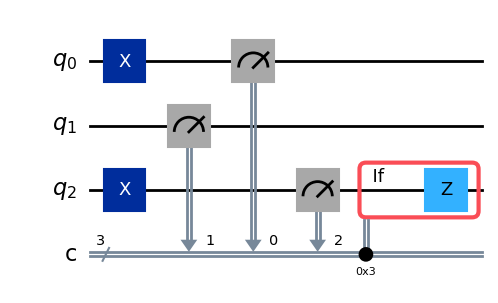

In [28]:
qc = mid_meas_whole_reg_false()
qc.draw('mpl')

## Optimised circuit

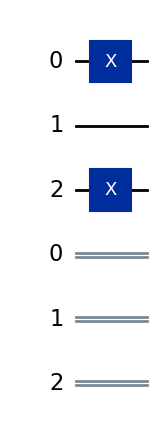

In [29]:
table, qc_opt = ConstantPropagation.optimize(qc)
qc_opt.draw('mpl')

## Istance

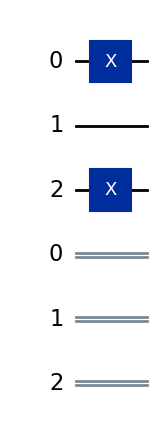

In [30]:
istance = ConstantPropagation.generate_istance(qc_opt)
istance.draw('mpl')